## Indikatoren für XAU berechnen und exportieren

In [13]:
import pandas as pd
import os
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator

# 📥 1. Daten laden
df = pd.read_csv("../dataset/output/xau_clean.csv", parse_dates=["date_xau"])
df = df.sort_values("date_xau")

# 🧹 2. Relevante Spalten in float konvertieren
for col in ["close_xau", "open_xau", "high_xau", "low_xau", "volume_xau"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Entferne Zeilen mit fehlendem Schlusskurs
df = df.dropna(subset=["close_xau"]).copy()

# 📊 3. Technische Indikatoren berechnen
# RSI
rsi = RSIIndicator(close=df["close_xau"], window=14)
df["RSI"] = rsi.rsi()

# MACD
macd = MACD(close=df["close_xau"], window_slow=26, window_fast=12, window_sign=9)
df["MACD"] = macd.macd()

# MA20
sma = SMAIndicator(close=df["close_xau"], window=20)
df["MA_20"] = sma.sma_indicator()

# Trendlinie (z. B. identisch mit MA_20)
df["Trendline"] = df["MA_20"]

# 🧾 4. Finale Spaltenauswahl und Umbenennung
df_out = df[[
    "date_xau", "open_xau", "high_xau", "low_xau", "close_xau",
    "RSI", "MACD", "MA_20", "Trendline", "volume_xau"
]]
df_out.columns = [
    "timestamp", "open", "high", "low", "close",
    "RSI", "MACD", "MA_20", "Trendline", "volume"
]

# 🔧 5. Runden und fehlende Werte als leere Felder
df_out = df_out.round(5).fillna("")

# ❗ 6. Falls Datei schon existiert → löschen
output_path = "../dataset/output/xau_technical_clean.csv"
if os.path.exists(output_path):
    os.remove(output_path)

# 📤 7. Speichern
df_out.to_csv(output_path, index=False, sep=",")

## Indikatoren für BTC berechnen und exportieren

In [14]:
import pandas as pd
import os
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator

# 📥 1. Daten laden
df = pd.read_csv("../dataset/output/btc_clean.csv", parse_dates=["date_btc"])
df = df.sort_values("date_btc")

# 🧹 2. Relevante Spalten in float konvertieren
for col in ["close_btc", "open_btc", "high_btc", "low_btc", "volume_usd_btc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Entferne Zeilen mit fehlendem Schlusskurs
df = df.dropna(subset=["close_btc"]).copy()

# 📊 3. Technische Indikatoren berechnen
# RSI
rsi = RSIIndicator(close=df["close_btc"], window=14)
df["RSI"] = rsi.rsi()

# MACD
macd = MACD(close=df["close_btc"], window_slow=26, window_fast=12, window_sign=9)
df["MACD"] = macd.macd()

# MA20
sma = SMAIndicator(close=df["close_btc"], window=20)
df["MA_20"] = sma.sma_indicator()

# Trendlinie (z. B. identisch mit MA_20)
df["Trendline"] = df["MA_20"]

# 🧾 4. Finale Spaltenauswahl und Umbenennung
df_out = df[[
    "date_btc", "open_btc", "high_btc", "low_btc", "close_btc",
    "RSI", "MACD", "MA_20", "Trendline", "volume_usd_btc"
]]
df_out.columns = [
    "timestamp", "open", "high", "low", "close",
    "RSI", "MACD", "MA_20", "Trendline", "volume"
]

# 🔧 5. Runden und fehlende Werte als leere Felder
df_out = df_out.round(5).fillna("")

# ❗ 6. Falls Datei schon existiert → löschen
output_path = "../dataset/output/btc_technical_clean.csv"
if os.path.exists(output_path):
    os.remove(output_path)

# 📤 7. Speichern
df_out.to_csv(output_path, index=False, sep=",")


## Merge technische Indikatoren für BTC und XAU

In [15]:
import pandas as pd
import os

# 📥 1. Dateien laden
btc_path = "../dataset/output/btc_technical_clean.csv"
xau_path = "../dataset/output/xau_technical_clean.csv"

btc = pd.read_csv(btc_path, parse_dates=["timestamp"])
xau = pd.read_csv(xau_path, parse_dates=["timestamp"])

# 📆 2. Merge auf Basis des Zeitstempels
merged = pd.merge(btc, xau, on="timestamp", how="inner", suffixes=("_btc", "_xau"))

# 🧽 3. Sortierung und Bereinigung
merged = merged.sort_values("timestamp").reset_index(drop=True)

# 🔍 3.1 Entferne Zeilen mit fehlenden technischen Indikatoren (z. B. am Anfang)
merged = merged.dropna(subset=["RSI_btc", "MACD_btc", "RSI_xau", "MACD_xau"]).copy()

# ❗ 4. Falls Datei schon existiert → löschen
output_path = "../dataset/output/final_merged_technical_dataset.csv"
if os.path.exists(output_path):
    os.remove(output_path)

# 💾 5. Speichern
merged.to_csv(output_path, index=False, sep=",")

print("✅ Merge abgeschlossen und gespeichert unter:", output_path)


✅ Merge abgeschlossen und gespeichert unter: ../dataset/output/final_merged_technical_dataset.csv


# Histogramme
### für Vergleich zwichen Preise und technischen Indikatoren für BTC und XAU nebeneinander

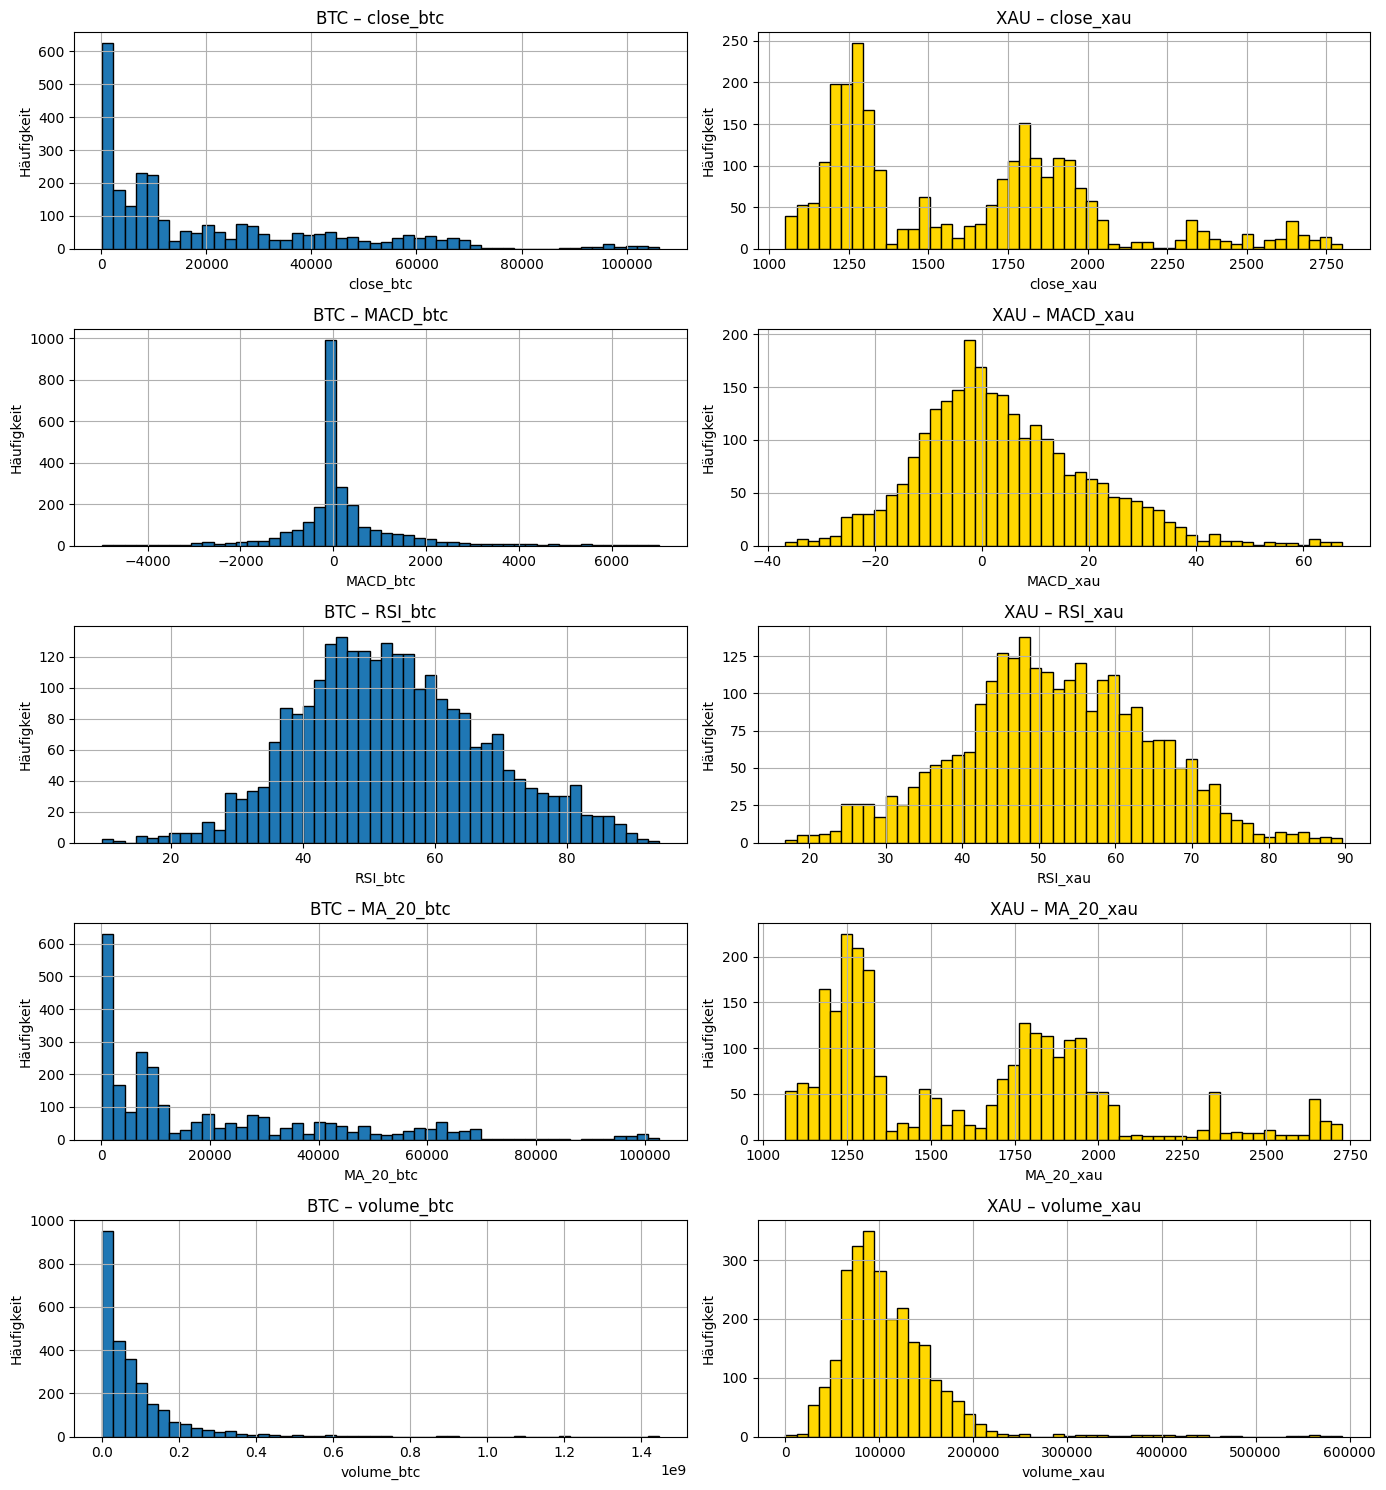

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 📥 1. Daten laden
df = pd.read_csv("../dataset/output/final_merged_technical_dataset.csv", parse_dates=["timestamp"])

# 🎯 Ziel:
# Vergleich der Verteilung technischer Indikatoren und Volumen für BTC und XAU – direkt nebeneinander dargestellt

# 🧩 2. Paare definieren (BTC ↔ XAU)
paare = [
    ("close_btc", "close_xau"),
    ("MACD_btc", "MACD_xau"),
    ("RSI_btc", "RSI_xau"),
    ("MA_20_btc", "MA_20_xau"),
    ("volume_btc", "volume_xau")  # 🔄 NEU: Volumenvergleich
]

# 📊 3. Plot
plt.figure(figsize=(14, 15))  # größer wegen zusätzlicher Zeile

for i, (btc_col, xau_col) in enumerate(paare, 1):
    # BTC links
    plt.subplot(len(paare), 2, (i - 1) * 2 + 1)
    df[btc_col].hist(bins=50, edgecolor="black")
    plt.title(f"BTC – {btc_col}")
    plt.xlabel(btc_col)
    plt.ylabel("Häufigkeit")

    # XAU rechts
    plt.subplot(len(paare), 2, (i - 1) * 2 + 2)
    df[xau_col].hist(bins=50, edgecolor="black", color="gold")
    plt.title(f"XAU – {xau_col}")
    plt.xlabel(xau_col)
    plt.ylabel("Häufigkeit")

plt.tight_layout()
plt.show()


# Korrelation als Heatmap
### berechnen und visualisieren die Korrelationen technischer Indikatoren innerhalb von Bitcoin sowie zwischen Bitcoin und Gold mithilfe zweier Heatmaps.

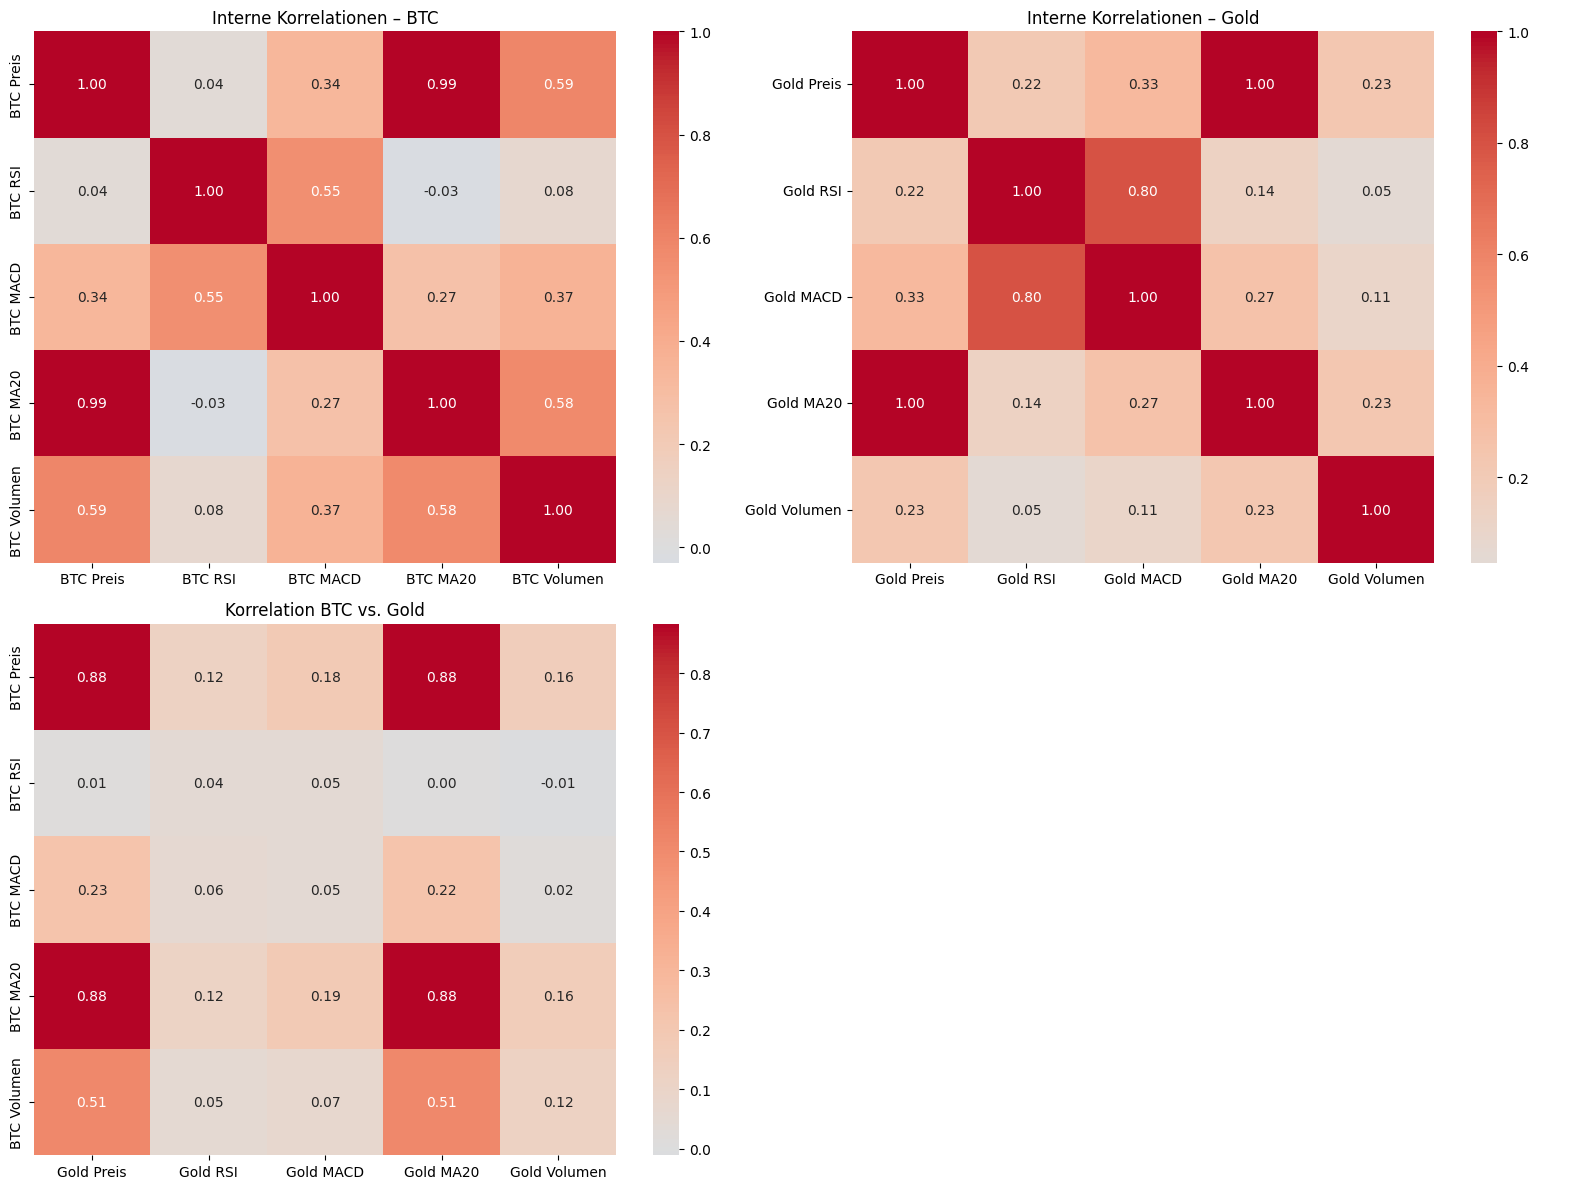

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spaltennamen definieren
btc_vars = ["close_btc", "RSI_btc", "MACD_btc", "MA_20_btc", "volume_btc"]
gold_vars = ["close_xau", "RSI_xau", "MACD_xau", "MA_20_xau", "volume_xau"]

cols = btc_vars + gold_vars
label_map = {
    "close_btc": "BTC Preis",
    "RSI_btc": "BTC RSI",
    "MACD_btc": "BTC MACD",
    "MA_20_btc": "BTC MA20",
    "volume_btc": "BTC Volumen",
    "close_xau": "Gold Preis",
    "RSI_xau": "Gold RSI",
    "MACD_xau": "Gold MACD",
    "MA_20_xau": "Gold MA20",
    "volume_xau": "Gold Volumen"
}

# Korrelation berechnen und Spalten umbenennen
df_korr = df[cols].corr()
df_korr.columns = [label_map[col] for col in df_korr.columns]
df_korr.index = [label_map[idx] for idx in df_korr.index]

btc_vars_named = [label_map[v] for v in btc_vars]
gold_vars_named = [label_map[v] for v in gold_vars]

btc_corr = df_korr.loc[btc_vars_named, btc_vars_named]
gold_corr = df_korr.loc[gold_vars_named, gold_vars_named]
cross_corr = df_korr.loc[btc_vars_named, gold_vars_named]

# 🔳 Layout: 2x2-Grid, untere rechte Zelle leer
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Interne BTC
sns.heatmap(btc_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, ax=axes[0, 0])
axes[0, 0].set_title("Interne Korrelationen – BTC")

# Interne Gold
sns.heatmap(gold_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, ax=axes[0, 1])
axes[0, 1].set_title("Interne Korrelationen – Gold")

# BTC vs. Gold zentriert unten (linke untere Zelle)
sns.heatmap(cross_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, ax=axes[1, 0])
axes[1, 0].set_title("Korrelation BTC vs. Gold")

# Rechte untere Zelle leer lassen
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


# Streudiagramme
### Preis vs Indikatoren

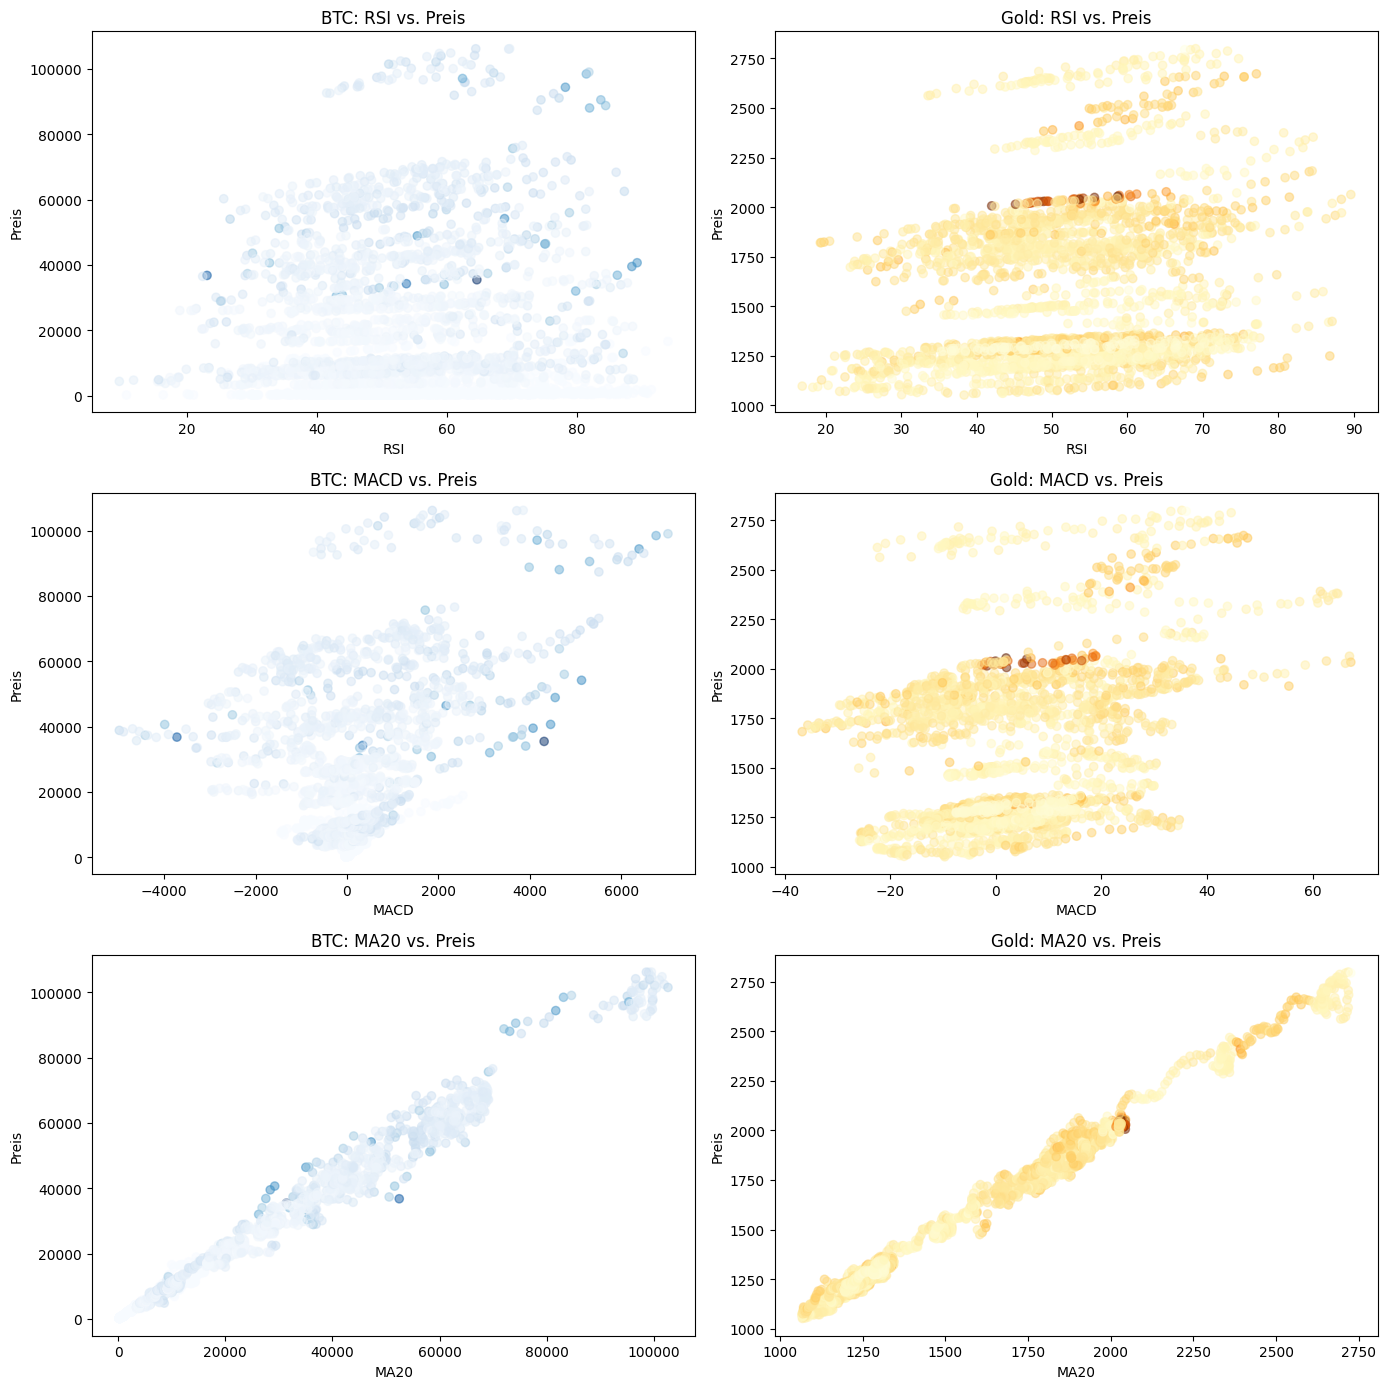

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))  # 3 Zeilen, 2 Spalten

# 🔹 BTC: RSI vs Preis
axes[0, 0].scatter(df["RSI_btc"], df["close_btc"], alpha=0.5, c=df["volume_btc"], cmap="Blues")
axes[0, 0].set_title("BTC: RSI vs. Preis")
axes[0, 0].set_xlabel("RSI")
axes[0, 0].set_ylabel("Preis")

# 🔸 Gold: RSI vs Preis
axes[0, 1].scatter(df["RSI_xau"], df["close_xau"], alpha=0.5, c=df["volume_xau"], cmap="YlOrBr")
axes[0, 1].set_title("Gold: RSI vs. Preis")
axes[0, 1].set_xlabel("RSI")
axes[0, 1].set_ylabel("Preis")

# 🔹 BTC: MACD vs Preis
axes[1, 0].scatter(df["MACD_btc"], df["close_btc"], alpha=0.5, c=df["volume_btc"], cmap="Blues")
axes[1, 0].set_title("BTC: MACD vs. Preis")
axes[1, 0].set_xlabel("MACD")
axes[1, 0].set_ylabel("Preis")

# 🔸 Gold: MACD vs Preis
axes[1, 1].scatter(df["MACD_xau"], df["close_xau"], alpha=0.5, c=df["volume_xau"], cmap="YlOrBr")
axes[1, 1].set_title("Gold: MACD vs. Preis")
axes[1, 1].set_xlabel("MACD")
axes[1, 1].set_ylabel("Preis")

# 🔹 BTC: MA20 vs Preis
axes[2, 0].scatter(df["MA_20_btc"], df["close_btc"], alpha=0.5, c=df["volume_btc"], cmap="Blues")
axes[2, 0].set_title("BTC: MA20 vs. Preis")
axes[2, 0].set_xlabel("MA20")
axes[2, 0].set_ylabel("Preis")

# 🔸 Gold: MA20 vs Preis
axes[2, 1].scatter(df["MA_20_xau"], df["close_xau"], alpha=0.5, c=df["volume_xau"], cmap="YlOrBr")
axes[2, 1].set_title("Gold: MA20 vs. Preis")
axes[2, 1].set_xlabel("MA20")
axes[2, 1].set_ylabel("Preis")

plt.tight_layout()
plt.show()
